# DATASCI 503, Group Work 3: ROC Curves and Logistic Regression

**Instructions:** During lab section, and afterward as necessary, you will collaborate in two-person teams (assigned by the GSI) to complete the problems that are interspersed below. The GSI will help individual teams encountering difficulty, make announcements addressing common issues, and help ensure progress for all teams. **During lab, feel free to flag down your GSI to ask questions at any point!**

In the assignment, you will will implement ROC from scratch and perform Logistic Regression on the NHANES dataset.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss, confusion_matrix, precision_recall_curve, roc_curve, auc
from sklearn.model_selection import train_test_split
import sklearn

import os

if os.path.isdir("fixtures"):
    !cp -n fixtures/* .

---

## Importing Data and Manipulation
In this section we will import and clean the NHANES data.


**Problem 1:** Load the NHANES Datasets

Load the three NHANES datasets (HDL, BMX, and DEMO) into dataframes. The data files are located in `data/NHANES/`.

Store the loaded dataframes in variables named `hdl`, `bmx`, and `demo`.

**Hint:** Use `pd.read_sas()` to load SAS .xpt files. See the [Pandas read_sas documentation](https://pandas.pydata.org/docs/reference/api/pandas.read_sas.html).

In [2]:
hdl = pd.read_sas("HDL_L.xpt")
bmx = pd.read_sas("BMX_L.xpt")
demo = pd.read_sas("DEMO_L.xpt")

In [3]:
# Visible tests
assert "hdl" in dir(), "Variable 'hdl' not defined"
assert "bmx" in dir(), "Variable 'bmx' not defined"
assert "demo" in dir(), "Variable 'demo' not defined"
assert isinstance(hdl, pd.DataFrame), "hdl should be a DataFrame"
assert isinstance(bmx, pd.DataFrame), "bmx should be a DataFrame"
assert isinstance(demo, pd.DataFrame), "demo should be a DataFrame"
print("All tests passed!")

All tests passed!


**Problem 2:** Join the Datasets

Join the three datasets together using their primary key (`SEQN`) with an inner join. Store the result in a variable named `df`.

**Hint:** Use `pd.merge()` to join dataframes. You may need to call it twice to join all three datasets. See the [Pandas merge documentation](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.merge.html).

In [4]:
# default inner join on SEQN
df = pd.merge(demo, hdl, on="SEQN").merge(bmx, on="SEQN")

In [5]:
### DO NOT MODIFY THIS CELL
print(df.head())

       SEQN  SDDSRVYR  RIDSTATR  RIAGENDR  RIDAGEYR  RIDAGEMN  RIDRETH1  \
0  130378.0      12.0       2.0       1.0      43.0       NaN       5.0   
1  130379.0      12.0       2.0       1.0      66.0       NaN       3.0   
2  130380.0      12.0       2.0       2.0      44.0       NaN       2.0   
3  130386.0      12.0       2.0       1.0      34.0       NaN       1.0   
4  130387.0      12.0       2.0       2.0      68.0       NaN       3.0   

   RIDRETH3  RIDEXMON  RIDEXAGM  ...  BMXLEG  BMILEG  BMXARML  BMIARML  \
0       6.0       2.0       NaN  ...    42.8     NaN     42.0      NaN   
1       3.0       2.0       NaN  ...    38.5     NaN     38.7      NaN   
2       2.0       1.0       NaN  ...    38.5     NaN     35.5      NaN   
3       1.0       1.0       NaN  ...    42.8     NaN     36.2      NaN   
4       3.0       2.0       NaN  ...    36.1     NaN     37.7      NaN   

   BMXARMC  BMIARMC  BMXWAIST  BMIWAIST  BMXHIP  BMIHIP  
0     35.7      NaN      98.3       NaN   102.

In [6]:
# Visible tests
assert "df" in dir(), "Variable 'df' not defined"
assert isinstance(df, pd.DataFrame), "df should be a DataFrame"
assert "SEQN" in df.columns, "df should have SEQN column"
print("All tests passed!")

All tests passed!


**Problem 3:** Select Predictor Variables

We will now choose a set of predictors to run a logistic regression to predict the level of HDL cholesterol.

In the code cell, filter your dataset to only contain the columns `SEQN`, your predictor variables, and the response variable `LBDHDD`. Rename `LBDHDD` to `HDL` for clarity. Store the result in a variable named `my_df`. You may also rename the other columns to more readable names.

Chosen predictors:
- `BMXBMI` (Body Mass Index)
- `RIDAGEYR` (Age in years at screening)
- `INDFMPIR` (Ratio of family income to poverty)

In [7]:
my_df = df.copy() 
my_df = my_df[['SEQN', 'RIDAGEYR', 'BMXBMI', 'INDFMPIR', 'LBDHDD']]
my_df.rename(columns = {'LBDHDD':'HDL'}, inplace = True)
my_df.columns


Index(['SEQN', 'RIDAGEYR', 'BMXBMI', 'INDFMPIR', 'HDL'], dtype='object')

In [8]:
### DO NOT MODIFY THIS CELL
print(my_df.head())

       SEQN  RIDAGEYR  BMXBMI  INDFMPIR   HDL
0  130378.0      43.0    27.0      5.00  45.0
1  130379.0      66.0    33.5      5.00  60.0
2  130380.0      44.0    29.7      1.41  49.0
3  130386.0      34.0    30.2      1.33  46.0
4  130387.0      68.0    42.6      1.32  42.0


In [9]:
# Visible tests
assert "my_df" in dir(), "Variable 'my_df' not defined"
assert isinstance(my_df, pd.DataFrame), "my_df should be a DataFrame"
assert len(my_df.columns) == 5, "my_df should have 5 columns (SEQN + HDL + predictors)"
print("All tests passed!")

All tests passed!


**Problem 4:** Handle Missing Values

Drop all rows with missing values from `my_df` since they do not help us much for modeling. Compute the fraction of observations we dropped and store the result in `dropped_fraction`.

In [10]:
nrow_original = my_df.shape[0]
my_df = my_df.dropna()
nrow_after = my_df.shape[0]
dropped_fraction = (nrow_original - nrow_after) / nrow_original

In [11]:
### DO NOT MODIFY THIS CELL
print(my_df.head())

       SEQN  RIDAGEYR  BMXBMI  INDFMPIR   HDL
0  130378.0      43.0    27.0      5.00  45.0
1  130379.0      66.0    33.5      5.00  60.0
2  130380.0      44.0    29.7      1.41  49.0
3  130386.0      34.0    30.2      1.33  46.0
4  130387.0      68.0    42.6      1.32  42.0


In [12]:
# Visible tests
assert my_df.isna().sum().sum() == 0, "my_df should have no missing values after dropna"
assert isinstance(dropped_fraction, float), "dropped_function should be a float"
assert 0 <= dropped_fraction <= 1
print("All tests passed!")

All tests passed!


---

## Introduction to Logistic Regression

In this section, we will start by introducting some logistic regression models. The data we will be using is synthetic and manually created by sampling from a multivariate Gaussian distribution.

For the Problems, you will keep working on the NHANES datasets.

In [13]:
%matplotlib inline

np.random.seed(12)
num_observations = 500

x1 = np.random.multivariate_normal([0, 0], [[1, 0.75], [0.75, 1]], num_observations)
x2 = np.random.multivariate_normal([0, 2], [[1, 0.75], [0.75, 1]], num_observations)

simulated_separableish_features = np.vstack((x1, x2)).astype(np.float32)
simulated_labels = np.hstack(
    (np.zeros(num_observations, dtype=int), np.ones(num_observations, dtype=int))
)

Let us visualize what the generated data looks like:

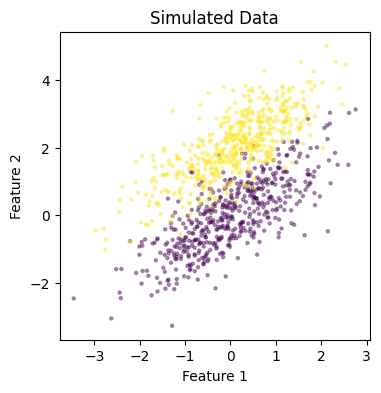

In [14]:
plt.figure(figsize=(4, 4))
plt.scatter(
    simulated_separableish_features[:, 0],
    simulated_separableish_features[:, 1],
    c=simulated_labels,
    alpha=0.4,
    s=5,
)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Simulated Data")
plt.show()

We now split the data into training and testing sets. We use a 70%/30% split.

In [15]:
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    simulated_separableish_features, simulated_labels, test_size=0.3, random_state=0
)

Now import logistic regression model from sklearn and train the model from the training data.

In [16]:
model_log = LogisticRegression()
model_log.fit(X_train_s, y_train_s)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


Logistic regression has trained successfully. We now use our fitted model to predict the probability of the binary outcomes in the test dataset.

In [17]:
y_prob_s = model_log.predict_proba(X_test_s)

# Show logistic regression's estimated probability mass function along with
# the true value of y_i for each test point
viz_table = pd.DataFrame(
    data=np.c_[y_prob_s, y_test_s],
    columns=[r"$\hat p(0|x_i)$", r"$\hat p(1|x_i)$", r"$y_i$"],
)
viz_table

,$\hat p(0|x_i)$,$\hat p(1|x_i)$,$y_i$
0,0.014040,0.985960,1.0
1,0.006952,0.993048,1.0
2,0.998837,0.001163,0.0
3,0.001565,0.998435,1.0
4,0.004637,0.995363,1.0
...,...,...,...
295,0.963290,0.036710,0.0
296,0.873139,0.126861,1.0
297,0.097838,0.902162,1.0
298,0.999505,0.000495,0.0


In [18]:
# Compute p(y_i | x_i) for each sample
pygx = y_prob_s[np.r_[0 : len(y_test_s)], y_test_s]
viz_table[r"$\hat p(y_i|x_i)$"] = pygx
viz_table

,$\hat p(0|x_i)$,$\hat p(1|x_i)$,$y_i$,$\hat p(y_i|x_i)$
0,0.014040,0.985960,1.0,0.985960
1,0.006952,0.993048,1.0,0.993048
2,0.998837,0.001163,0.0,0.998837
3,0.001565,0.998435,1.0,0.998435
4,0.004637,0.995363,1.0,0.995363
...,...,...,...,...
295,0.963290,0.036710,0.0,0.963290
296,0.873139,0.126861,1.0,0.126861
297,0.097838,0.902162,1.0,0.902162
298,0.999505,0.000495,0.0,0.999505


In [19]:
# Compute average log likelihood
np.mean(np.log(pygx))

np.float64(-0.16193651730866185)

In [20]:
# sklearn provides a convenience function for computing the estimated cross-entropy
# i.e., the negative log likelihood (NLL), which is just the negative of what
# we computed above
log_loss(y_test_s, y_prob_s)

0.16193651730866185

**Problem 5:** Create Binary HDL Indicator

In order to fit a logistic regression model to the NHANES data, we first need to construct a binary outcome.

High-density lipoprotein (HDL) cholesterol is often called the "good" cholesterol because higher levels are generally associated with a lower risk of heart disease.
An HDL of 60 mg/dL or higher is often viewed as protective against heart disease. This is typically the level you'd like to aim for, if possible.

Convert your HDL variable to a binary indicator that is `True` when HDL is **at least** 60 mg/dL and `False` otherwise. Store this in a column named `HDL_healthy`.

In [21]:
my_df['HDL_healthy'] = (my_df['HDL'] >= 60)
my_df['HDL_healthy'].value_counts()

HDL_healthy
False    4126
True     1831
Name: count, dtype: int64

In [22]:
### DO NOT MODIFY THIS CELL
print(my_df.head())

       SEQN  RIDAGEYR  BMXBMI  INDFMPIR   HDL  HDL_healthy
0  130378.0      43.0    27.0      5.00  45.0        False
1  130379.0      66.0    33.5      5.00  60.0         True
2  130380.0      44.0    29.7      1.41  49.0        False
3  130386.0      34.0    30.2      1.33  46.0        False
4  130387.0      68.0    42.6      1.32  42.0        False


In [23]:
# Visible tests
assert "HDL_healthy" in my_df.columns, "my_df should have 'HDL_healthy' column"
assert my_df["HDL_healthy"].dtype == bool, "HDL_healthy should be boolean type"
assert my_df["HDL_healthy"].any(), "Some samples should have HDL_healthy=True"
assert not my_df["HDL_healthy"].all(), "Some samples should have HDL_healthy=False"
print("All tests passed!")

All tests passed!


**Problem 6:** Split Data into Training and Test Sets

Separate the data into training and testing splits. Use an 80%/20% split with `random_state=8`.

Store the results in variables named `X_train`, `X_test`, `y_train`, and `y_test`.

**Hint:** Use `sklearn.model_selection.train_test_split()` imported above. See the [documentation](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html).

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    my_df[['RIDAGEYR', 'BMXBMI', 'INDFMPIR']], my_df['HDL_healthy'], test_size=0.2, random_state=8)

In [25]:
# Test assertions
assert "X_train" in dir(), "Variable 'X_train' not defined"
assert "X_test" in dir(), "Variable 'X_test' not defined"
assert "y_train" in dir(), "Variable 'y_train' not defined"
assert "y_test" in dir(), "Variable 'y_test' not defined"
assert len(X_train) > len(X_test), "Training set should be larger than test set"
print("All tests passed!")

All tests passed!


**Problem 7:** Train a Logistic Regression Model

Train a logistic regression model on the training data. Store the trained model in a variable named `model`.

**Hint:** Use `sklearn.linear_model.LogisticRegression()` imported above. See the [documentation](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html).

In [26]:
model = LogisticRegression()
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [27]:
# Test assertions
assert "model" in dir(), "Variable 'model' not defined"
assert hasattr(model, "predict"), "model should have a predict method"
assert hasattr(model, "predict_proba"), "model should have a predict_proba method"
print("All tests passed!")

All tests passed!


---

## Hard Classifiers and Thresholding

This section will focus on  *hard classifiers*, models that given an input predict the binary outcome. This is contrasted with soft classifies (like the one we have so far), that estimate the conditional probability of the response given an input. 

We'll start by making a hard classifier by thresholding our estimate of the conditional pmf.

$$\hat y(x) = \begin{cases} 1 & \mathrm{if}\ \hat p(1|x)>t \\ 0 & \mathrm{otherwise}\end{cases}$$

We'll start with $t=0.6$, which is pretty arbitrary. You can also play around with different values and see how things change.

In [28]:
thresh = 0.6
y_pred_s = np.where(y_prob_s[:, 1] > thresh, 1, 0)
pd.DataFrame({"phat(1|x_i)": y_prob_s[:, 1], "yhat(x_i)": y_pred_s})

,phat(1|x_i),yhat(x_i)
0,0.985960,1
1,0.993048,1
2,0.001163,0
3,0.998435,1
4,0.995363,1
...,...,...
295,0.036710,0
296,0.126861,0
297,0.902162,1
298,0.000495,0


In [29]:
cnf_matrix = confusion_matrix(y_test_s, y_pred_s)
cnf_matrix

array([[135,   9],
       [ 15, 141]])

In [30]:
# You can also create a confusion matrix using Pandas
cm_pd = pd.crosstab(y_test_s, y_pred_s, rownames=["Actual"], colnames=["Predicted"])
cm_pd

Predicted,0,1
Actual,,
0,135,9
1,15,141


In [31]:
# Pandas can also create row summaries and column summaries
cm_pd = pd.crosstab(y_test_s, y_pred_s, rownames=["Actual"], colnames=["Predicted"], margins=True)
cm_pd

Predicted,0,1,All
Actual,,,
0,135,9,144
1,15,141,156
All,150,150,300


In [32]:
# Look at some metrics that are special for binary classification, where we have
# a "negative" and "positive" class
# Here "positive" is class 1 and "negative" is class 0

FP = cnf_matrix[0, 1]  # it is "negative" (class 0) but we predict +1
FN = cnf_matrix[1, 0]
TP = cnf_matrix[1, 1]
TN = cnf_matrix[0, 0]

FP = float(FP)
FN = float(FN)
TP = float(TP)
TN = float(TN)

metrics_series = pd.Series(
    {
        # Sensitivity, hit rate, recall, or true positive rate
        "TPR": TP / (TP + FN),
        # Specificity or true negative rate
        "TNR": TN / (TN + FP),
        # Precision or positive predictive value
        "PPV": TP / (TP + FP),
        # Negative predictive value
        "NPV": TN / (TN + FN),
        # Fall out or false positive rate
        "FPR": FP / (FP + TN),
        # False negative rate
        "FNR": FN / (TP + FN),
        # False discovery rate
        "FDR": FP / (TP + FP),
    }
)
metrics_series

TPR    0.903846
TNR    0.937500
PPV    0.940000
NPV    0.900000
FPR    0.062500
FNR    0.096154
FDR    0.060000
dtype: float64

Let's make a curve, evaluating the precision and recall for many different hard classifiers based on many different thresholds. 
`sklearn` makes this easy for you with the `roc_curve` method.

Intuitively, you can view the ROC curve through the lens of hypothesis testing. Each threshold defines a different decision rule for declaring an observation “positive.” The $x$-axis, FPR, is the Type I error rate (false-alarm probability among truly negative cases), while the $y$-axis, TPR, is the power (probability of correctly flagging truly positive cases). A curve closer to the top-left indicates higher power at the same Type I error, and a larger AUC summarizes that the classifier achieves strong power across a wide range of Type I error levels.

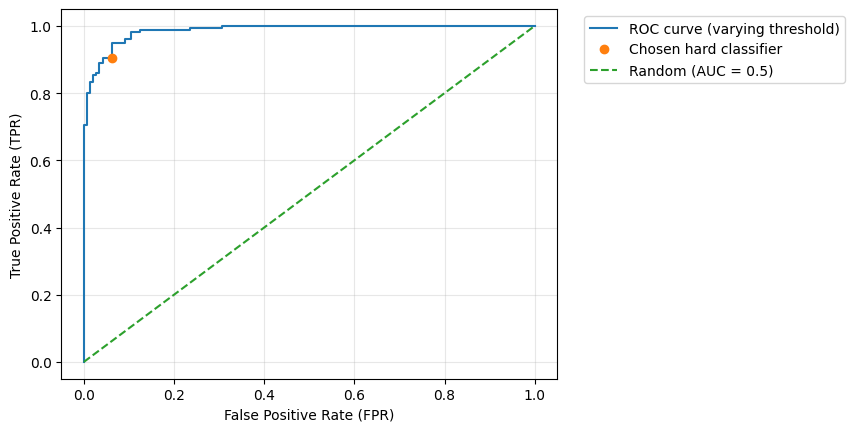

In [33]:
fpr, tpr, thresh = sklearn.metrics.roc_curve(y_test_s, y_prob_s[:, 1])

plt.figure()
plt.plot(fpr, tpr, label="ROC curve (varying threshold)")
plt.plot(
    [metrics_series.FPR],
    [metrics_series.TPR],
    "o",
    label="Chosen hard classifier",
)

plt.plot([0, 1], [0, 1], "--", label="Random (AUC = 0.5)")  # optional reference
plt.legend(bbox_to_anchor=(1.04, 1), loc="upper left")
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.grid(True, alpha=0.3)
plt.show()

**Problem 8:** Generate Predictions

Generate both the predicted probabilities and the default binary predictions for the test set.

Store the predicted probabilities in a variable named `predicted_probs` and the binary predictions in a variable named `predicted_hdl_healthy`.

**Hint:** Use `model.predict_proba()` for probabilities and `model.predict()` for binary predictions.

In [34]:
predicted_probs = model.predict_proba(X_test)
predicted_hdl_healthy = model.predict(X_test)
print(f"Average predicted probability: {predicted_probs.mean(axis=0)}")

Average predicted probability: [0.68910119 0.31089881]


In [35]:
# Visible tests
assert "predicted_probs" in dir(), "Variable 'predicted_probs' not defined"
assert "predicted_hdl_healthy" in dir(), "Variable 'predicted_hdl_healthy' not defined"
assert predicted_probs.shape[0] == len(X_test), "predicted_probs should have same length as X_test"
assert predicted_probs.shape[1] == 2, "predicted_probs should have 2 columns (one per class)"
print("All tests passed!")

All tests passed!


**Problem 9:** Evaluate with sklearn's ROC

Use sklearn's `roc_curve` and `auc` functions to evaluate the logistic regression model. This will serve as a sanity check that our own implementation (in the next problem) is close to accurate.

Store the results in variables named `fpr`, `tpr`, `thresholds`, and `roc_auc`.

**Hint:** See the [roc_curve documentation](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_curve.html) and [auc documentation](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.auc.html).

AUC: 0.6844


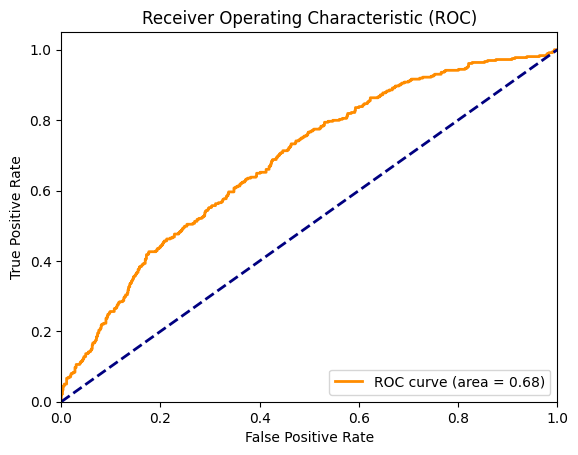

In [36]:
from sklearn.metrics import auc, roc_curve

fpr, tpr, thresholds = roc_curve(y_test, predicted_probs[:, 1])
roc_auc = auc(fpr, tpr)

print(f"AUC: {roc_auc:.4f}")

plt.figure()
plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC curve (area = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC)")
plt.legend(loc="lower right")
plt.show()

In [37]:
# Test assertions
assert "fpr" in dir(), "Variable 'fpr' not defined"
assert "tpr" in dir(), "Variable 'tpr' not defined"
assert "roc_auc" in dir(), "Variable 'roc_auc' not defined"
assert 0 <= roc_auc <= 1, "AUC should be between 0 and 1"
assert roc_auc > 0.5, "AUC should be better than random (> 0.5)"
print("All tests passed!")

All tests passed!


---

**Problem 10:** Implement ROC from Scratch

Implement your own ROC function and evaluate your logistic regression on it. You may **not** wrap functions that already compute ROC (e.g., `sklearn.metrics.roc_curve`). You may use `sklearn.metrics.confusion_matrix` to compute the confusion matrix for each threshold.

Your function should:
1. Take `y_true` (true labels) and `predicted_probs_positive` (predicted probabilities for the positive class) as inputs
2. Use at least 1000 thresholds evenly spaced between 0 and 1
3. For each threshold, compute the FPR and TPR from the confusion matrix
4. Return lists of FPR values, TPR values, and thresholds

**Recall:**
- TPR (True Positive Rate) = TP / (TP + FN)
- FPR (False Positive Rate) = FP / (FP + TN)

Store your results in `my_fprs`, `my_tprs`, and `my_thresholds`.

In [38]:
from sklearn.metrics import confusion_matrix


def compute_roc(y_true, predicted_probs_positive):
    """
    Compute the ROC curve from scratch.

    Parameters
    ----------
    y_true : array-like
        The true labels of the test set.
    predicted_probs_positive : array-like
        The predicted probabilities of the positive class for the test set.

    Returns
    -------
    fpr_list : list
        A list of false positive rates for each threshold.
    tpr_list : list
        A list of true positive rates for each threshold.
    thresholds : ndarray
        The thresholds used to calculate the rates.
    """
    thresholds = np.sort(np.unique(predicted_probs_positive))
    fpr_list = []
    tpr_list = []

    for thresh in thresholds:
        y_pred = np.where(predicted_probs_positive >= thresh, 1, 0)
        cm = confusion_matrix(y_true, y_pred)
        TN, FP, FN, TP = cm.ravel()

        FPR = FP / (FP + TN) if (FP + TN) > 0 else 0
        TPR = TP / (TP + FN) if (TP + FN) > 0 else 0

        fpr_list.append(FPR)
        tpr_list.append(TPR)

    return fpr_list, tpr_list, thresholds




AUC (custom implementation): 0.6844


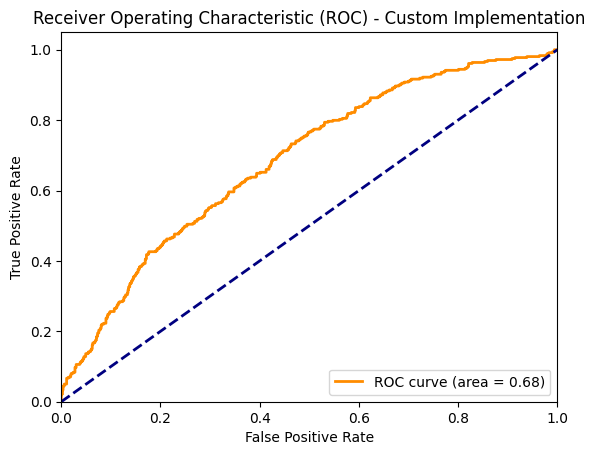

In [39]:
## DO NOT MODIFY THIS CELL
my_fprs, my_tprs, my_thresholds = compute_roc(y_test, predicted_probs[:, 1])

# Plot the ROC curve
my_roc_auc = auc(my_fprs, my_tprs)
print(f"AUC (custom implementation): {my_roc_auc:.4f}")

plt.figure()
plt.plot(my_fprs, my_tprs, color="darkorange", lw=2, label=f"ROC curve (area = {my_roc_auc:.2f})")
plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC) - Custom Implementation")
plt.legend(loc="lower right")
plt.show()

In [40]:
# Test assertions
assert "my_fprs" in dir(), "Variable 'my_fprs' not defined"
assert "my_tprs" in dir(), "Variable 'my_tprs' not defined"
assert "my_thresholds" in dir(), "Variable 'my_thresholds' not defined"
assert len(my_thresholds) >= 1000, "Should use at least 1000 thresholds"
assert (
    len(my_fprs) == len(my_tprs) == len(my_thresholds)
), "FPR, TPR, and thresholds should have same length"
print("All tests passed!")

All tests passed!


---

**Problem 11:** Find the Optimal Threshold

A common approach for selecting a final threshold is to find the point on the ROC curve that is closest to the ideal point (0, 1), which represents perfect classification (FPR=0, TPR=1).

Write code that finds this optimal threshold and the corresponding FPR and TPR values. Store them in variables named `optimal_threshold`, `optimal_fpr`, and `optimal_tpr`.

Then, plot the ROC curve with a marker at the optimal point.

**Hint:** The Euclidean distance from a point $(fpr, tpr)$ to (0, 1) is: $\sqrt{fpr^2 + (1 - tpr)^2}$

In [42]:
# Calculate Euclidean distances from each point (fpr, tpr) to the ideal point (0, 1)
distances = np.sqrt(np.array(my_fprs)**2 + (1 - np.array(my_tprs))**2)

# Find the index of the minimum distance
optimal_idx = np.argmin(distances)

# Extract the optimal threshold and corresponding FPR and TPR
optimal_threshold = my_thresholds[optimal_idx]
optimal_fpr = my_fprs[optimal_idx]
optimal_tpr = my_tprs[optimal_idx]

Optimal threshold: 0.3302
Optimal FPR: 0.3721
Optimal TPR: 0.6323


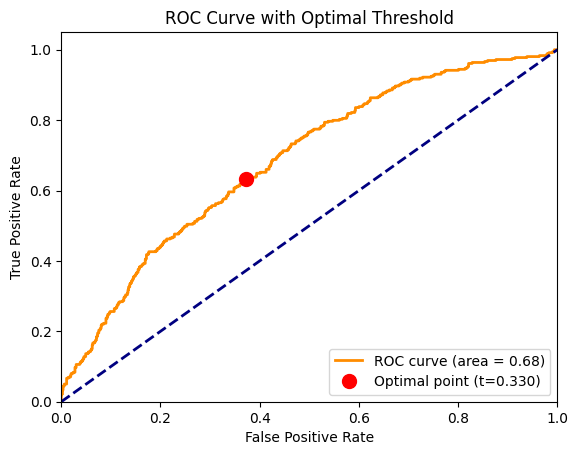

In [43]:
### DO NOT MODIFY
print(f"Optimal threshold: {optimal_threshold:.4f}")
print(f"Optimal FPR: {optimal_fpr:.4f}")
print(f"Optimal TPR: {optimal_tpr:.4f}")

# Plot the ROC curve with the optimal point
plt.figure()
plt.plot(my_fprs, my_tprs, color="darkorange", lw=2, label=f"ROC curve (area = {my_roc_auc:.2f})")
plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")
plt.plot(
    optimal_fpr,
    optimal_tpr,
    "ro",
    markersize=10,
    label=f"Optimal point (t={optimal_threshold:.3f})",
)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve with Optimal Threshold")
plt.legend(loc="lower right")
plt.show()

In [44]:
# Test assertions
assert "optimal_threshold" in dir(), "Variable 'optimal_threshold' not defined"
assert "optimal_fpr" in dir(), "Variable 'optimal_fpr' not defined"
assert "optimal_tpr" in dir(), "Variable 'optimal_tpr' not defined"
assert 0 <= optimal_threshold <= 1, "Optimal threshold should be between 0 and 1"
assert 0 <= optimal_fpr <= 1, "Optimal FPR should be between 0 and 1"
assert 0 <= optimal_tpr <= 1, "Optimal TPR should be between 0 and 1"
print("All tests passed!")

All tests passed!
